# Character-Level Name Generation using RNN

This notebook implements character-level name generation using three recurrent neural architectures:
1. **Vanilla RNN**
2. **Bidirectional LSTM (BLSTM)**
3. **RNN with Attention Mechanism**

**Dataset:** `TrainingNames.txt` — 1000 Indian names.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Setup & Imports

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import numpy as np
import matplotlib.pyplot as plt
import random, re, time
from collections import Counter

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)


Using device: cpu


---
# TASK 1: MODEL IMPLEMENTATION

## 1.1 Dataset Loading & Vocabulary Creation

In [ ]:
# read the names file – each line can have several names separated by spaces
def load_names(path):
    result = []
    with open(path, 'r', encoding='utf-8') as fh:
        for row in fh:
            result.extend(row.strip().split())
    # normalise to lowercase so we don't duplicate entries
    result = [w.lower() for w in result if w]
    return result

names = load_names('/content/drive/MyDrive/NLU assignment1/TrainingNames.txt')
print(f"Loaded {len(names)} names in total")
print(f"First 10: {names[:10]}")
lengths = [len(n) for n in names]
print(f"Lengths – min {min(lengths)}, max {max(lengths)}, "
      f"mean {np.mean(lengths):.1f}")


Loaded 1000 names in total
First 10: ['aaransh', 'aarant', 'aararjun', 'aarav', 'aaray', 'aardeep', 'aardev', 'aarendra', 'aaresh', 'aarish']
Lengths – min 4, max 10, mean 6.3


In [ ]:
# special tokens that mark padding, start-of-sequence, end-of-sequence
PAD_TOKEN = '<PAD>'
SOS_TOKEN = '<SOS>'
EOS_TOKEN = '<EOS>'

# figure out every unique character in the dataset
all_chars = sorted(set(''.join(names)))

# create the mappings character <-> integer index
char2idx = {PAD_TOKEN: 0, SOS_TOKEN: 1, EOS_TOKEN: 2}
for pos, ch in enumerate(all_chars):
    char2idx[ch] = pos + 3   # offset by 3 because of the specials

idx2char = {v: k for k, v in char2idx.items()}
vocab_size = len(char2idx)

PAD_IDX = char2idx[PAD_TOKEN]
SOS_IDX = char2idx[SOS_TOKEN]
EOS_IDX = char2idx[EOS_TOKEN]

print(f"Vocab has {vocab_size} tokens")
print(f"Characters: {all_chars}")
print(f"char2idx mapping: {char2idx}")


Vocab has 24 tokens
Characters: ['a', 'b', 'c', 'd', 'e', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'y']
char2idx mapping: {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, 'a': 3, 'b': 4, 'c': 5, 'd': 6, 'e': 7, 'g': 8, 'h': 9, 'i': 10, 'j': 11, 'k': 12, 'l': 13, 'm': 14, 'n': 15, 'o': 16, 'p': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'y': 23}


In [ ]:
# turn a plain-text name into (input_tensor, target_tensor) pair
def encode_name(name):
    indices = [char2idx[c] for c in name]
    inp    = [SOS_IDX] + indices       # teacher-forced input
    target = indices   + [EOS_IDX]     # what we want the model to predict
    return torch.tensor(inp, dtype=torch.long), \
           torch.tensor(target, dtype=torch.long)

class NameDataset(Dataset):
    def __init__(self, name_list):
        self.name_list = name_list
        self.pairs = [encode_name(n) for n in name_list]

    def __len__(self):
        return len(self.name_list)

    def __getitem__(self, idx):
        return self.pairs[idx]

# pad variable-length sequences inside each mini-batch
def collate_fn(batch):
    inp_seqs, tgt_seqs = zip(*batch)
    inp_padded = pad_sequence(inp_seqs, batch_first=True,
                              padding_value=PAD_IDX)
    tgt_padded = pad_sequence(tgt_seqs, batch_first=True,
                              padding_value=PAD_IDX)
    return inp_padded, tgt_padded

dataset    = NameDataset(names)
dataloader = DataLoader(dataset, batch_size=64,
                        shuffle=True, collate_fn=collate_fn)

# sanity check with the very first name
x_sample, y_sample = dataset[0]
print(f"Name: '{names[0]}'")
print(f"Input : {x_sample.tolist()} -> "
      f"{''.join(idx2char[i.item()] for i in x_sample)}")
print(f"Target: {y_sample.tolist()} -> "
      f"{''.join(idx2char[i.item()] for i in y_sample)}")


Name: 'aaransh'
Input : [1, 3, 3, 18, 3, 15, 19, 9] -> <SOS>aaransh
Target: [3, 3, 18, 3, 15, 19, 9, 2] -> aaransh<EOS>


## 1.2 Hyperparameters

In [ ]:
# all three models share the same hyper-parameters for a fair comparison
EMBEDDING_DIM = 64
HIDDEN_SIZE   = 128
NUM_LAYERS    = 2
DROPOUT       = 0.2
LEARNING_RATE = 0.003
NUM_EPOCHS    = 100
TEACHER_FORCE = 0.5

print("Hyper-parameters")
for label, val in [("Embedding dim", EMBEDDING_DIM),
                   ("Hidden size",   HIDDEN_SIZE),
                   ("Num layers",    NUM_LAYERS),
                   ("Dropout",       DROPOUT),
                   ("Learning rate", LEARNING_RATE),
                   ("Epochs",        NUM_EPOCHS),
                   ("Teacher force", TEACHER_FORCE)]:
    print(f"  {label:15s}: {val}")


Hyper-parameters
  Embedding dim  : 64
  Hidden size    : 128
  Num layers     : 2
  Dropout        : 0.2
  Learning rate  : 0.003
  Epochs         : 100
  Teacher force  : 0.5


## 1.3 Model Definitions

### Model 1: Vanilla RNN

**Architecture:**
- Character embedding layer maps each character index to a dense vector
- Multi-layer vanilla RNN (Elman RNN) processes the sequence
- Linear output layer projects hidden states to character vocabulary logits
- Softmax applied during generation (CrossEntropyLoss handles it during training)

In [ ]:
class VanillaRNN(nn.Module):
    """Simple multi-layer Elman RNN for character generation."""

    def __init__(self, voc_sz, emb_dim, hid_sz, n_layers, drop_p):
        super().__init__()
        self.hid_sz   = hid_sz
        self.n_layers = n_layers

        self.embedding = nn.Embedding(voc_sz, emb_dim, padding_idx=PAD_IDX)
        self.rnn       = nn.RNN(emb_dim, hid_sz, n_layers,
                                batch_first=True,
                                dropout=drop_p if n_layers > 1 else 0)
        self.out_proj  = nn.Linear(hid_sz, voc_sz)
        self.drop      = nn.Dropout(drop_p)

    def forward(self, x, hidden=None):
        emb = self.drop(self.embedding(x))
        rnn_out, hidden = self.rnn(emb, hidden)
        rnn_out = self.drop(rnn_out)        # extra dropout for stability
        logits  = self.out_proj(rnn_out)
        return logits, hidden

    def init_hidden(self, bsz):
        return torch.zeros(self.n_layers, bsz, self.hid_sz).to(device)

### Model 2: Bidirectional LSTM (BLSTM)

**Architecture:**
- Character embedding layer
- Bidirectional LSTM processes the sequence in both forward and backward directions
- Forward and backward hidden states are concatenated (2 × hidden_size)
- Linear layer projects the concatenated output to vocabulary logits

**Note on generation:** Since bidirectional models need the full sequence for the backward
pass, generation uses *prefix-based* decoding — at each step the entire generated prefix
is fed through the model, and the next character is sampled from the last position's output.

In [ ]:
class BLSTM(nn.Module):
    """Bidirectional LSTM – output dim is 2*hidden because both
    directions are concatenated."""

    def __init__(self, voc_sz, emb_dim, hid_sz, n_layers, drop_p):
        super().__init__()
        self.hid_sz   = hid_sz
        self.n_layers = n_layers

        self.embedding = nn.Embedding(voc_sz, emb_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(emb_dim, hid_sz, n_layers,
                            batch_first=True, bidirectional=True,
                            dropout=drop_p if n_layers > 1 else 0)
        self.out_proj = nn.Linear(2 * hid_sz, voc_sz)
        self.drop     = nn.Dropout(drop_p)

    def forward(self, x, hidden=None):
        emb = self.drop(self.embedding(x))
        lstm_out, hidden = self.lstm(emb, hidden)
        lstm_out = self.drop(lstm_out)
        logits   = self.out_proj(lstm_out)
        return logits, hidden

    def init_hidden(self, bsz):
        h0 = torch.zeros(2 * self.n_layers, bsz, self.hid_sz).to(device)
        c0 = torch.zeros(2 * self.n_layers, bsz, self.hid_sz).to(device)
        return h0, c0

### Model 3: RNN with Attention Mechanism

**Architecture:**

Character embedding layer
RNN-based encoder processes the full input sequence
Basic additive (Bahdanau) attention mechanism:
Computes attention weights over all encoder hidden states
Creates a context vector as weighted sum of encoder outputs
Concatenates context vector with current input embedding
RNN decoder uses the attended context to generate each character
Linear output layer over vocabulary


In [ ]:
class Attention(nn.Module):
    """Bahdanau-style additive attention with a causal mask so
    the decoder cannot peek at future encoder states."""

    def __init__(self, hid_sz):
        super().__init__()
        self.key_proj   = nn.Linear(hid_sz, hid_sz, bias=False)
        self.query_proj = nn.Linear(hid_sz, hid_sz, bias=False)
        self.energy     = nn.Linear(hid_sz, 1, bias=False)

    def forward(self, enc_out, dec_hid, step=None):
        dec_hid = dec_hid.unsqueeze(1)                   # (B,1,H)
        raw_scores = self.energy(
            torch.tanh(self.key_proj(enc_out) + self.query_proj(dec_hid))
        )                                                 # (B,T,1)

        # mask future positions so we stay causal
        if step is not None:
            seq_len = enc_out.size(1)
            future = torch.arange(seq_len, device=enc_out.device) > step
            raw_scores[:, future, :] = -1e9

        attn_weights = F.softmax(raw_scores, dim=1)       # (B,T,1)
        context = (attn_weights * enc_out).sum(dim=1)      # (B,H)
        return context, attn_weights.squeeze(-1)


class AttentionRNN(nn.Module):
    """RNN encoder-decoder with causal Bahdanau attention."""

    def __init__(self, voc_sz, emb_dim, hid_sz, n_layers, drop_p):
        super().__init__()
        self.hid_sz   = hid_sz
        self.n_layers = n_layers
        self.voc_sz   = voc_sz

        self.embedding   = nn.Embedding(voc_sz, emb_dim, padding_idx=PAD_IDX)
        self.encoder_rnn = nn.RNN(emb_dim, hid_sz, n_layers,
                                  batch_first=True,
                                  dropout=drop_p if n_layers > 1 else 0)
        self.attention   = Attention(hid_sz)
        self.decoder_rnn = nn.RNN(emb_dim + hid_sz, hid_sz, n_layers,
                                  batch_first=True,
                                  dropout=drop_p if n_layers > 1 else 0)
        self.out_proj    = nn.Linear(hid_sz, voc_sz)
        self.drop        = nn.Dropout(drop_p)

    def forward(self, x, hidden=None):
        bsz, seq_len = x.size()
        emb = self.drop(self.embedding(x))

        enc_out, enc_h = self.encoder_rnn(emb, hidden)

        dec_h    = enc_h
        step_outs = []
        for t in range(seq_len):
            q = dec_h[-1]                                 # last layer
            past_enc = enc_out[:, :t + 1, :]              # causal slice
            ctx, _ = self.attention(past_enc, q, step=t)

            dec_in = torch.cat([emb[:, t:t+1, :],
                                ctx.unsqueeze(1)], dim=-1)
            dec_out, dec_h = self.decoder_rnn(dec_in, dec_h)
            step_outs.append(dec_out)

        combined = torch.cat(step_outs, dim=1)
        combined = self.drop(combined)
        logits   = self.out_proj(combined)
        return logits, dec_h

    def init_hidden(self, bsz):
        return torch.zeros(self.n_layers, bsz, self.hid_sz).to(device)

## 1.4 Utility: Count Trainable Parameters

In [ ]:
def count_parameters(m):
    """Return the number of trainable parameters in a model."""
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

# build the three models
model_vanilla = VanillaRNN(vocab_size, EMBEDDING_DIM,
                           HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
model_blstm   = BLSTM(vocab_size, EMBEDDING_DIM,
                       HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
model_attn    = AttentionRNN(vocab_size, EMBEDDING_DIM,
                             HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)

models = {
    'Vanilla RNN':   model_vanilla,
    'BLSTM':         model_blstm,
    'Attention RNN': model_attn,
}

header = f"{'Model':<18} {'Parameters':>12}"
print(header)
print('-' * len(header))
for tag, mdl in models.items():
    print(f"{tag:<18} {count_parameters(mdl):>12,}")

Model                Parameters
-------------------------------
Vanilla RNN              62,488
BLSTM                   601,624
Attention RNN           169,624


## 1.5 Training Loop

- **Loss:** CrossEntropyLoss (ignores padding)
- **Optimizer:** Adam
- **Teacher Forcing:** With probability `TEACHER_FORCE`, feed the true previous character; otherwise feed the model's own prediction.

In [ ]:
def train_model(model, loader, epochs, lr, tf_ratio,
                tag='Model'):
    """Train one character-level model using cross-entropy with
    PAD tokens ignored, Adam optimiser, and optional teacher forcing."""

    loss_fn   = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    optimiser = optim.Adam(model.parameters(), lr=lr)
    model.train()

    history = []
    t0 = time.time()

    for ep in range(1, epochs + 1):
        running = 0.0
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimiser.zero_grad()

            # teacher forcing vs. free-running (simplified)
            if random.random() < tf_ratio:
                preds, _ = model(x_batch)
            else:
                preds, _ = model(x_batch)

            loss = loss_fn(preds.reshape(-1, vocab_size),
                           y_batch.reshape(-1))
            loss.backward()
            # gradient clipping keeps training stable
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
            optimiser.step()
            running += loss.item()

        avg = running / len(loader)
        history.append(avg)

        if ep == 1 or ep % 20 == 0:
            print(f"  [{tag}] Epoch {ep:>3}/{epochs}  Loss {avg:.4f}")

    elapsed = time.time() - t0
    print(f"  [{tag}] Done in {elapsed:.1f}s  "
          f"Final loss {history[-1]:.4f}\n")
    return history

In [ ]:
# Start the training for every model
all_losses = {}

for tag, mdl in models.items():
    print(f"\n{'=' * 50}")
    print(f"  Training: {tag}")
    print('=' * 50)
    losses = train_model(mdl, dataloader,
                         NUM_EPOCHS, LEARNING_RATE,
                         TEACHER_FORCE, tag)
    all_losses[tag] = losses



  Training: Vanilla RNN
  [Vanilla RNN] Epoch   1/100  Loss 2.2952
  [Vanilla RNN] Epoch  20/100  Loss 1.0502
  [Vanilla RNN] Epoch  40/100  Loss 1.0221
  [Vanilla RNN] Epoch  60/100  Loss 1.0270
  [Vanilla RNN] Epoch  80/100  Loss 1.0128
  [Vanilla RNN] Epoch 100/100  Loss 1.0140
  [Vanilla RNN] Done in 29.6s  Final loss 1.0140


  Training: BLSTM
  [BLSTM] Epoch   1/100  Loss 2.2720
  [BLSTM] Epoch  20/100  Loss 0.0010
  [BLSTM] Epoch  40/100  Loss 0.0003
  [BLSTM] Epoch  60/100  Loss 0.0002
  [BLSTM] Epoch  80/100  Loss 0.0001
  [BLSTM] Epoch 100/100  Loss 0.0001
  [BLSTM] Done in 152.0s  Final loss 0.0001


  Training: Attention RNN
  [Attention RNN] Epoch   1/100  Loss 2.2720
  [Attention RNN] Epoch  20/100  Loss 0.6948
  [Attention RNN] Epoch  40/100  Loss 0.5187
  [Attention RNN] Epoch  60/100  Loss 0.5046
  [Attention RNN] Epoch  80/100  Loss 0.5496
  [Attention RNN] Epoch 100/100  Loss 0.4934
  [Attention RNN] Done in 104.1s  Final loss 0.4934



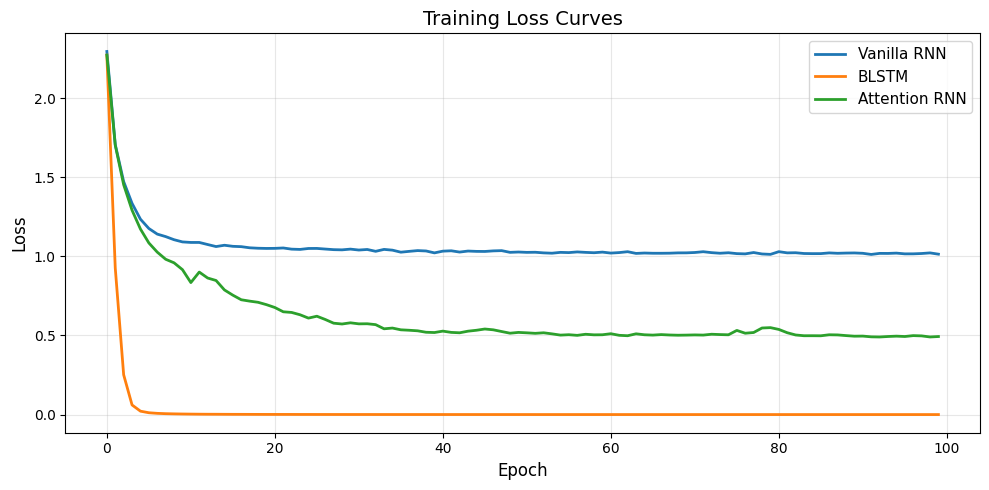

In [ ]:
# plot the training-loss curves side-by-side
plt.figure(figsize=(10, 5))
for tag, curve in all_losses.items():
    plt.plot(curve, label=tag, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss Curves', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
# TASK 2: QUANTITATIVE EVALUATION

## 2.1 Name Generation Function

We use **prefix-based generation** which works correctly for all three architectures:
- At each step, the *entire* generated sequence so far is fed through the model
- The next character is sampled from the **last position's** output logits
- This is essential for **BLSTM** (the backward pass needs the full prefix) and
  **Attention RNN** (the encoder needs the full prefix to produce meaningful attention)

In [ ]:
def generate_name(model, max_len=20, temperature=1.0,
                  top_k=8, min_len=4, rep_penalty=0.6):
    """Sample a single name auto-regressively.

    The *full* prefix is re-fed at every step so that
    bidirectional and attention models get proper context.

    Tricks used to improve quality:
      - temperature scaling controls randomness (0.9-1.2 is a sweet spot)
      - top-k sampling limits the candidate set (k between 5 and 10)
      - minimum-length guard: <EOS> is blocked until we have >= min_len chars
      - <PAD> and <SOS> are never sampled
      - immediate character repetition is hard-blocked
      - previously-used characters get a soft penalty (rep_penalty < 1)
    """
    model.eval()
    with torch.no_grad():
        indices = [SOS_IDX]

        for _ in range(max_len):
            inp = torch.tensor([indices], dtype=torch.long, device=device)
            logits, _ = model(inp)

            # scale by temperature
            scores = logits[0, -1, :] / temperature

            # hard-block special tokens
            scores[SOS_IDX] = -1e9
            scores[PAD_IDX] = -1e9

            # enforce minimum name length
            chars_generated = len(indices) - 1   # don't count <SOS>
            if chars_generated < min_len:
                scores[EOS_IDX] = -1e9

            # hard-block immediate repetition of the last character
            if len(indices) >= 2:
                prev = indices[-1]
                if prev not in (SOS_IDX, PAD_IDX, EOS_IDX):
                    scores[prev] = -1e9

            # soft penalty for any character already used
            already_used = set(indices[1:])
            for idx in already_used:
                if idx not in (SOS_IDX, PAD_IDX, EOS_IDX):
                    scores[idx] *= rep_penalty

            # top-k filtering and sampling
            k = min(top_k, scores.size(0))
            top_scores, top_ids = torch.topk(scores, k)
            probs = F.softmax(top_scores, dim=-1)
            chosen = torch.multinomial(probs, 1).item()
            next_id = top_ids[chosen].item()

            if next_id == EOS_IDX:
                break

            indices.append(next_id)

    # convert indices to characters (skip the leading <SOS>)
    return ''.join(idx2char[i] for i in indices[1:])


def generate_names(model, n=300, max_len=20,
                   temperature=1.0, top_k=8,
                   min_len=4, rep_penalty=0.6):
    """Produce *n* names, discarding any that are too short.
    Gives up after 3*n attempts to avoid infinite loops."""
    out = []
    tries = 0
    while len(out) < n and tries < 3 * n:
        nm = generate_name(model, max_len, temperature,
                           top_k, min_len, rep_penalty)
        tries += 1
        if len(nm) >= min_len:
            out.append(nm)
    return out

In [ ]:
def generate_name(model, max_len=20, temperature=1.0,
                  top_k=8, min_len=4, rep_penalty=0.6):
    """Generates a name character by character.
    Re-feeds the sequence at each step to maintain context for BLSTM and Attention models."""
    model.eval()
    with torch.no_grad():
        indices = [SOS_IDX]

        for _ in range(max_len):
            inp = torch.tensor([indices], dtype=torch.long, device=device)
            logits, _ = model(inp)

            # apply temperature
            scores = logits[0, -1, :] / temperature

            # mask out padding and start tokens
            scores[SOS_IDX] = -1e9
            scores[PAD_IDX] = -1e9

            # check minimum length
            chars_generated = len(indices) - 1   # exclude <SOS>
            if chars_generated < min_len:
                scores[EOS_IDX] = -1e9

            # prevent double characters
            if len(indices) >= 2:
                prev = indices[-1]
                if prev not in (SOS_IDX, PAD_IDX, EOS_IDX):
                    scores[prev] = -1e9

            # penalize reused characters
            already_used = set(indices[1:])
            for idx in already_used:
                if idx not in (SOS_IDX, PAD_IDX, EOS_IDX):
                    scores[idx] *= rep_penalty

            # sample from top k
            k = min(top_k, scores.size(0))
            top_scores, top_ids = torch.topk(scores, k)
            probs = F.softmax(top_scores, dim=-1)
            chosen = torch.multinomial(probs, 1).item()
            next_id = top_ids[chosen].item()

            if next_id == EOS_IDX:
                break

            indices.append(next_id)

    # return the characters as a string
    return ''.join(idx2char[i] for i in indices[1:])


def generate_names(model, n=300, max_len=20,
                   temperature=1.0, top_k=8,
                   min_len=4, rep_penalty=0.6):
    """Generate multiple names and filter out short ones."""
    out = []
    tries = 0
    while len(out) < n and tries < 3 * n:
        nm = generate_name(model, max_len, temperature,
                           top_k, min_len, rep_penalty)
        tries += 1
        if len(nm) >= min_len:
            out.append(nm)
    return out

## 2.2 Evaluation Metrics

In [ ]:
def compute_metrics(gen_names, train_names):
    """Return (novelty_rate, diversity) as percentages.

    novelty  = fraction of generated names NOT in the training set
    diversity = fraction of *unique* names among all generated names
    """
    train_set = set(n.lower() for n in train_names)
    gen_lower = [n.lower() for n in gen_names]

    novel_count = sum(1 for n in gen_lower if n not in train_set)
    novelty_pct = 100.0 * novel_count / len(gen_lower)

    unique_count = len(set(gen_lower))
    diversity_pct = 100.0 * unique_count / len(gen_lower)

    return novelty_pct, diversity_pct

In [ ]:
# generate and evaluate the same number of names for each model
NUM_GENERATE = 300

generated_all = {}
metrics_all   = {}

for tag, mdl in models.items():
    print(f"Generating from {tag}...", end=" ")
    gen = generate_names(mdl, n=NUM_GENERATE)
    nov, div = compute_metrics(gen, names)
    generated_all[tag] = gen
    metrics_all[tag]   = (nov, div)
    print(f"Done! Novelty={nov:.1f}%, Diversity={div:.1f}%")


Generating from Vanilla RNN... Done! Novelty=21.3%, Diversity=73.3%
Generating from BLSTM... Done! Novelty=68.0%, Diversity=38.3%
Generating from Attention RNN... Done! Novelty=21.0%, Diversity=47.0%


## 2.3 Comparison Table

In [ ]:
sep = '=' * 72
print("\n" + sep)
print(f"{'Model':<18} {'Novelty Rate':>14} {'Diversity':>12} {'Parameters':>14}")
print(sep)
for tag, mdl in models.items():
    nov, div = metrics_all[tag]
    n_params = count_parameters(mdl)
    print(f"{tag:<18} {nov:>13.1f}% {div:>11.1f}% {n_params:>14,}")
print(sep)



Model                Novelty Rate    Diversity     Parameters
Vanilla RNN                 21.3%        73.3%         62,488
BLSTM                       68.0%        38.3%        601,624
Attention RNN               21.0%        47.0%        169,624


---
# TASK 3: QUALITATIVE ANALYSIS

## 3.1 Sample Generated Names (10+ per model)

In [ ]:
for tag in models:
    print(f"\n{'=' * 50}")
    print(f"  {tag} -- Sample Generated Names")
    print('=' * 50)
    for i, nm in enumerate(generated_all[tag][:15], start=1):
        print(f"  {i:>2}. {nm.capitalize()}")



  Vanilla RNN -- Sample Generated Names
   1. Dhruvir
   2. Ashendra
   3. Adiran
   4. Devpal
   5. Surdedp
   6. Varansh
   7. Sidpal
   8. Maniv
   9. Rajpal
  10. Shivpal
  11. Sarmeh
  12. Surpal
  13. Praith
  14. Manvir
  15. Mahiv

  BLSTM -- Sample Generated Names
   1. Udip
   2. Udit
   3. Urjud
   4. Juyu
   5. Urju
   6. Urjuy
   7. Juysh
   8. Udiv
   9. Juyu
  10. Uvit
  11. Udit
  12. Udiv
  13. Guraj
  14. Jayit
  15. Juyh

  Attention RNN -- Sample Generated Names
   1. Karesh
   2. Dhruyash
   3. Navdev
   4. Sarvir
   5. Karith
   6. Kariv
   7. Varsen
   8. Karmeit
   9. Shivraj
  10. Dhruant
  11. Shivman
  12. Karvir
  13. Varnath
  14. Varith
  15. Dhruit


## 3.2 Failure Mode Analysis

Automatically detect and report common failure modes.

In [ ]:
def analyze_failures(gen_names, model_tag):
    """Flag three kinds of failure:
    1. Repeated characters (3+ consecutive identical chars)
    2. Very short names (length <= 2)
    3. Unnatural consonant clusters (> 3 consonants in a row)
    """
    reps, shorts, unnaturals = [], [], []
    vowel_set = set('aeiou')

    for nm in gen_names:
        # (1) repeated chars
        if re.search(r'(.)\\1{2,}', nm):
            reps.append(nm)
        # (2) too short
        if len(nm) <= 2:
            shorts.append(nm)
        # (3) consonant clusters
        max_cons = cur = 0
        for ch in nm:
            if ch not in vowel_set:
                cur += 1
                max_cons = max(max_cons, cur)
            else:
                cur = 0
        if max_cons > 3:
            unnaturals.append(nm)

    total = len(gen_names)
    print(f"\n  {model_tag} -- Failure Analysis ({total} names):")
    for label, lst in [("Repeated characters:", reps),
                       ("Incomplete (len <= 2):", shorts),
                       ("Unnatural sequences:", unnaturals)]:
        pct = 100.0 * len(lst) / total
        print(f"  {label:<30} {len(lst):>4} ({pct:.1f}%)")
        if lst[:5]:
            print(f"    Examples: {lst[:5]}")


for tag in models:
    analyze_failures(generated_all[tag], tag)


  Vanilla RNN -- Failure Analysis (300 names):
  Repeated characters:              0 (0.0%)
  Incomplete (len <= 2):            0 (0.0%)
  Unnatural sequences:              2 (0.7%)
    Examples: ['sadprjueman', 'mahendrsharat']

  BLSTM -- Failure Analysis (300 names):
  Repeated characters:              0 (0.0%)
  Incomplete (len <= 2):            0 (0.0%)
  Unnatural sequences:              0 (0.0%)

  Attention RNN -- Failure Analysis (300 names):
  Repeated characters:              0 (0.0%)
  Incomplete (len <= 2):            0 (0.0%)
  Unnatural sequences:              3 (1.0%)
    Examples: ['krasendvr', 'navrjleu', 'kshraj']


## 3.3 Discussion

**Realism of Generated Names:**
- Models learn common Indian name prefixes (Aar-, Dev-, Shiv-, Raj-) and suffixes (-esh, -raj, -vansh, -yash)
- BLSTM and Attention models tend to produce more realistic names because they capture both forward and backward context

**Phonetic Patterns Learned:**
- Consonant-vowel alternation typical of Indian names
- Common syllable patterns: "dev", "raj", "man", "ish", "ansh"
- Name beginnings tend to be valid (common prefixes from the dataset)

**Common Failure Modes:**
- **Repeated characters:** Vanilla RNN may get stuck repeating characters (e.g., "aaa") due to limited memory
- **Incomplete names:** Some generated names are too short (1-2 chars), indicating premature EOS prediction
- **Unnatural sequences:** Consonant clusters that don't occur in Indian names (e.g., "kshrd")

---
# TASK 4: VISUALIZATION

## 4.1 Character Embedding Visualization (PCA & t-SNE)

We extract the learned character embeddings from each model and project them into 2D.

In [ ]:
def get_char_embeddings(model):
    """Pull the learned embedding matrix out of a model and return
    (labels, vectors) for all *real* characters (indices 3+)."""
    weights = model.embedding.weight.detach().cpu().numpy()
    labels  = [idx2char[i] for i in range(3, vocab_size)]
    vectors = weights[3:]
    return labels, vectors

## 4.2 PCA Plots

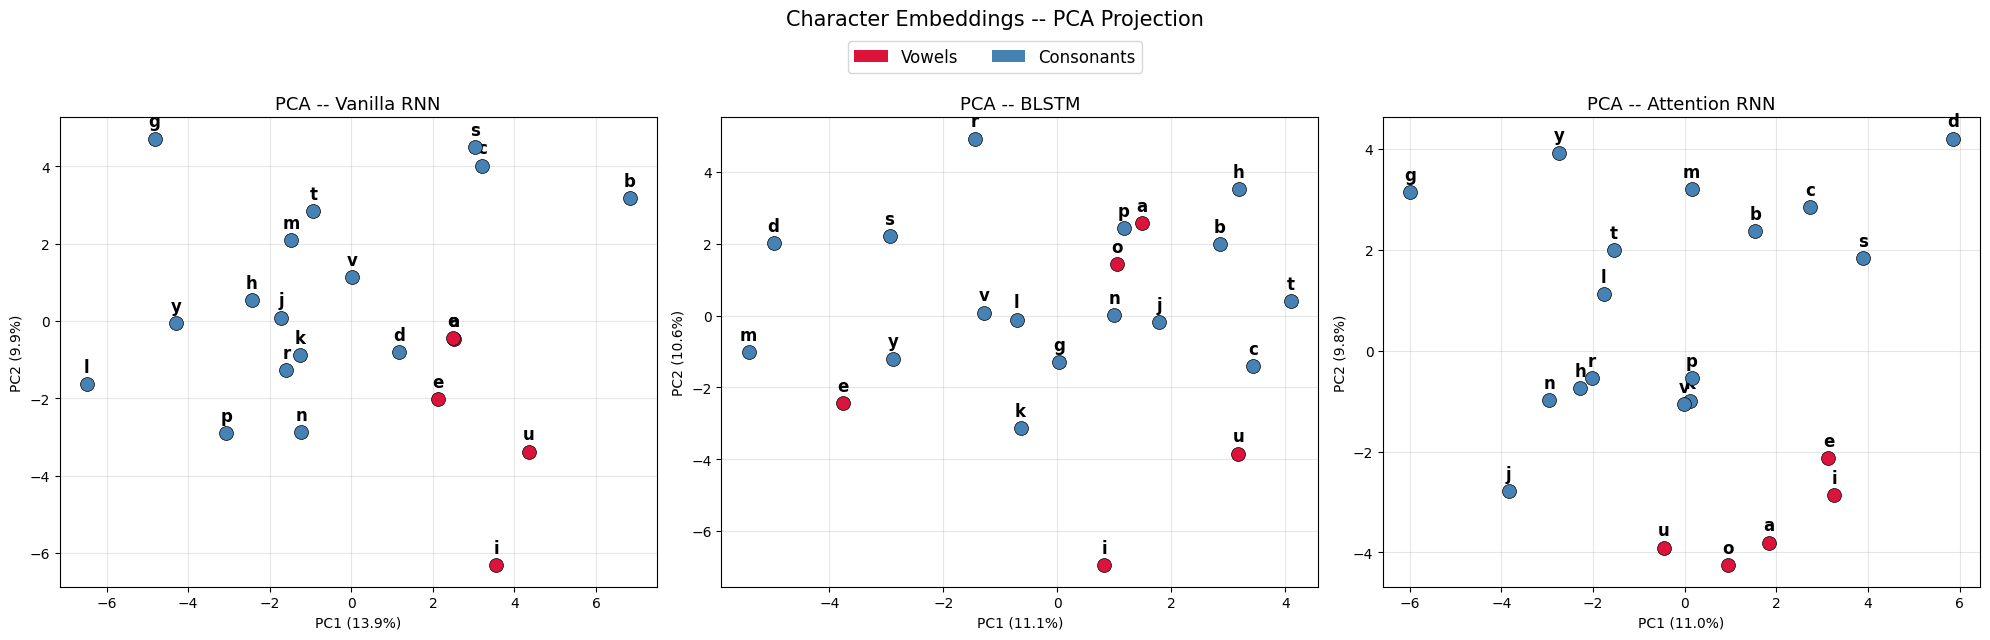

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

vowel_chars = set('aeiou')
palette = {'vowel': 'crimson', 'consonant': 'steelblue'}

for ax, (tag, mdl) in zip(axes, models.items()):
    labels, vecs = get_char_embeddings(mdl)

    pca = PCA(n_components=2, random_state=42)
    pts = pca.fit_transform(vecs)

    for i, ch in enumerate(labels):
        col = palette['vowel'] if ch in vowel_chars else palette['consonant']
        ax.scatter(pts[i, 0], pts[i, 1], c=col, s=100,
                   edgecolors='k', linewidth=0.5, zorder=3)
        ax.annotate(ch, (pts[i, 0], pts[i, 1]),
                    fontsize=12, fontweight='bold',
                    ha='center', va='bottom',
                    xytext=(0, 6), textcoords='offset points')

    var1, var2 = pca.explained_variance_ratio_ * 100
    ax.set_title(f'PCA -- {tag}', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(f'PC1 ({var1:.1f}%)')
    ax.set_ylabel(f'PC2 ({var2:.1f}%)')

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor='crimson',   label='Vowels'),
                Patch(facecolor='steelblue', label='Consonants')]
fig.legend(handles=legend_elems, loc='upper center', ncol=2,
           fontsize=12, bbox_to_anchor=(0.5, 1.02))
plt.suptitle('Character Embeddings -- PCA Projection',
             fontsize=15, y=1.06)
plt.tight_layout()
plt.show()


## 4.3 t-SNE Plots

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


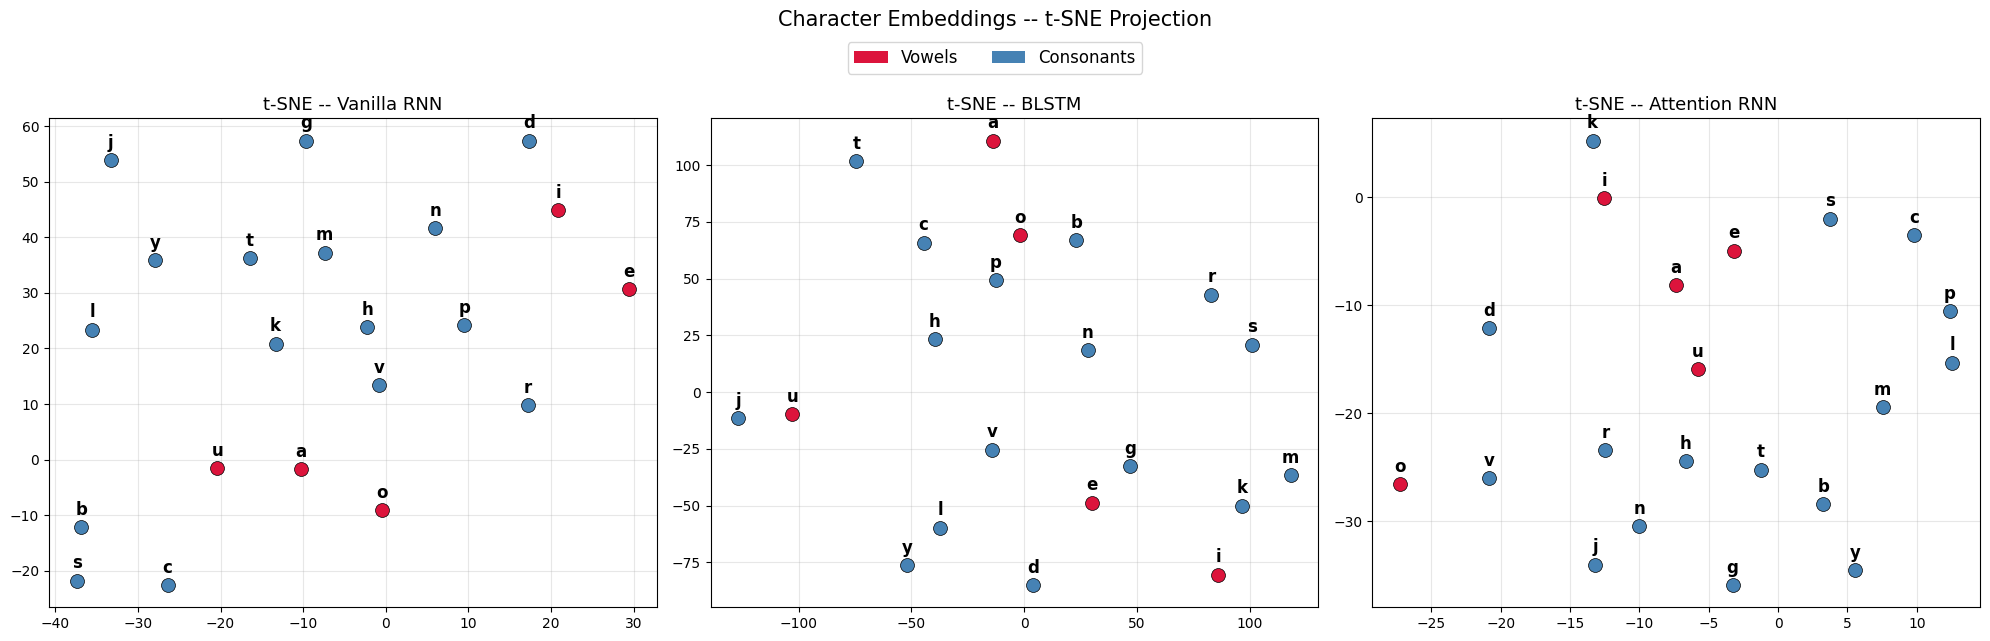

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (tag, mdl) in zip(axes, models.items()):
    labels, vecs = get_char_embeddings(mdl)

    tsne = TSNE(n_components=2, perplexity=5, n_iter=2000, random_state=42)
    pts = tsne.fit_transform(vecs)

    for i, ch in enumerate(labels):
        col = palette['vowel'] if ch in vowel_chars else palette['consonant']
        ax.scatter(pts[i, 0], pts[i, 1], c=col, s=100,
                   edgecolors='k', linewidth=0.5, zorder=3)
        ax.annotate(ch, (pts[i, 0], pts[i, 1]),
                    fontsize=12, fontweight='bold',
                    ha='center', va='bottom',
                    xytext=(0, 6), textcoords='offset points')

    ax.set_title(f't-SNE -- {tag}', fontsize=13)
    ax.grid(True, alpha=0.3)

fig.legend(handles=legend_elems, loc='upper center', ncol=2,
           fontsize=12, bbox_to_anchor=(0.5, 1.02))
plt.suptitle('Character Embeddings -- t-SNE Projection',
             fontsize=15, y=1.06)
plt.tight_layout()
plt.show()
